<a href="https://colab.research.google.com/github/catarina1532/pml/blob/main/assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Machine Learning regression model to predict the quality of wine using the Wine Quality dataset

The dataset contains 4898 wine samples, each described by several physicochemical properties such as acidity, sugar content, chlorides, and alcohol.

The goal of the model is to learn the relationship between these chemical measurements and the quality score assigned to each wine.

**Task:**

Train a regression model to predict the response variable "quality" given the available explanatory variables for the Wine Quality data set.

##1. Import libraries

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

Import the required python libraries including pandas for data handling, matplotlib for plotting, scikit-learn for dataset splitting, and tensorflow for building the machine learning model.

##2. Load Wine Quality dataset

In [47]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
df = pd.read_csv(url, sep=";")

Load the Wine Quality dataset directly from the UC Irvine Machine Learning repository into a pandas dataframe.

##3. Explore data

In [48]:
print("### First 5 rows of the DataFrame:\n")
print(df.head())

print("\n### DataFrame Info:\n")
df.info()

print("\n### Descriptive Statistics:\n")
print(df.describe())

print("\n### Missing Values per column:\n")
print(df.isnull().sum())

print("\n### Distribution of 'quality' (target variable):\n")
print(df['quality'].value_counts())

### First 5 rows of the DataFrame:

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  
0      8.8        6  
1     

Perform initial exploratory data analysis including displaying head, info, descriptive statistics, checking for missing values, and examining the distribution of the target variable.

##4. Define input and output variables - keywords: INPUT and OUTPUT

In [49]:
X = df.drop("quality", axis=1)

In [50]:
y = df["quality"]

The input variables, stored in X, represent the features used by the model to make predictions. In this dataset they include chemical measurements such as acidity, alcohol, and sugar levels.

The output variable, stored in y, is the wine quality score (between 0 and 10).

The goal of the model is to learn a function that maps the input variables to the output variable.

##5. Train/test split - keywords: TRAIN DATASET and TEST DATASET

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

To evaluate the performance of the model, the dataset is divided into two parts.

The train dataset is used to train the model and allow it to learn patterns in the data.

The test dataset is used to evaluate the model on data it has never seen before.

In this notebook the dataset is split into 80% training data and 20% test data.

##6. Feature scaling

In [52]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Machine learning models often perform better when input variables are scaled.

Standardization transforms variables so they have:

- mean = 0
- standard deviation = 1

This improves the stability and speed of training.

##7. Define the model - keyword: MODEL

In [53]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


The model is implemented as a neural network using tensorflow keras.

The network contains two hidden layers that learn patterns in the input variables and an output layer that produces a predicted wine quality value.

##8. Define the loss function - keyword: LOSS FUNCTION

In [54]:
model.compile(
    optimizer='adam',
    loss='mse'
)

To train the model we must define a loss function.

The loss function measures how different the predicted values are from the true values.

Mean Squared Error (MSE) is the regression evaluation metric used, which calculates the squared difference between predicted and actual wine quality.

The training process aims to minimize this loss.

##9. Train the model (epochs and batch) - keywords: EPOCH and BATCH



In [55]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 26.5918 - val_loss: 4.7641
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.5454 - val_loss: 2.2763
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.4710 - val_loss: 1.8861
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8670 - val_loss: 1.6669
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6837 - val_loss: 1.4217
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.6617 - val_loss: 1.2503
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1938 - val_loss: 1.1050
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1428 - val_loss: 0.9823
Epoch 9/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0365 - val_loss: 0.8754
Epoch 10/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8288 - val_loss: 0.7872
Epoch 11/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7661 - val_loss: 0.7316
Epoch 12/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7389 - val_l

The model is trained using the training dataset.

During training there are two important concepts: epochs and batches.

An epoch is one complete pass through the entire training dataset.

Instead of processing the entire dataset at once, the data is divided into smaller groups called batches.

Each batch is used to update the model’s parameters, allowing the model to gradually improve its predictions.

##10. Predict on test dataset - keyword: PREDICT

In [56]:
y_pred = model.predict(X_test)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


After the model finishes training, it can be used to predict wine quality for new data.

In this step the model generates predictions for the test dataset, which allows us to evaluate its performance.

##11. Plot results

###Plot 1: actual vs predicted

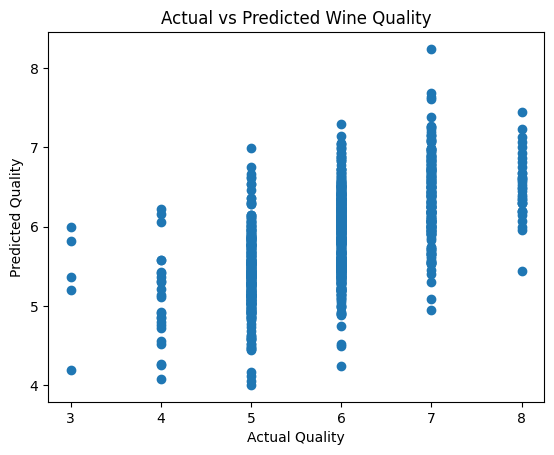

In [57]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs Predicted Wine Quality")
plt.show()

The first required plot compares actual wine quality values with the predicted values produced by the model.

If the model performs well, the points should lie close to a diagonal line, indicating that predictions are close to the true values.

###Plot 2: loss vs epoch

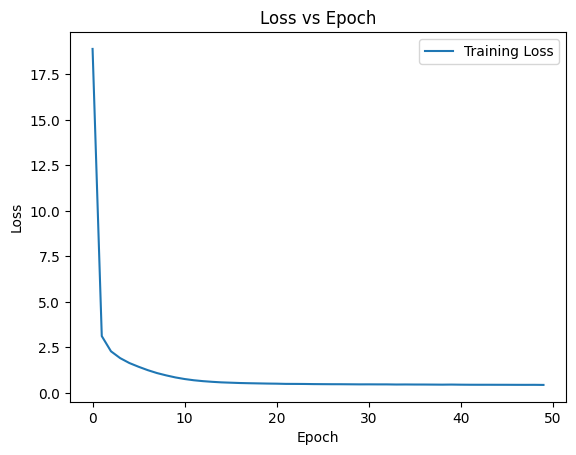

In [58]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

The second required plot shows loss versus epochs during training.

This plot illustrates how the error decreases as the model learns from the training data.

A decreasing curve indicates that the model is successfully improving its predictions.


**Conclusion:**

This notebook demonstrates the complete machine learning workflow.

We defined inputs and outputs, split the dataset into train and test datasets, created a model, defined a loss function, trained the model using epochs and batches, and used the model to predict wine quality.

Finally, we evaluated the model using the required plots.